In [1]:
"""
Utility script to quickly view tonemapped images directly from a packed HDF5 chunk file, 
without needing the heavy raw EXR files on disk.

Usage:
    python data_generation/view_h5.py renderformer/tmp/dataset_single_obj_v2/nmr_dataset_chunk_0000.h5 --scene scene_0000
"""

import os
import argparse
import h5py
import numpy as np
import matplotlib.pyplot as plt

def hdr_to_ldr(hdr_img, gamma=2.2):
    """Simple tonemapping by applying gamma correction and clipping."""
    # Prevent negative values before power
    ldr = np.clip(hdr_img, 0, None)
    ldr = np.power(ldr, 1.0 / gamma)
    ldr = np.clip(ldr, 0, 1)
    return ldr

def view_scenes(h5_path, scene=None):
    if not os.path.exists(h5_path):
        print(f"Error: File {h5_path} does not exist.")
        return

    with h5py.File(h5_path, 'r') as f:
        scenes = list(f.keys())
        if not scenes:
            print("Error: H5 file is empty.")
            return
            
        scene_name = scene
        if scene_name is None:
            scene_name = scenes[0]
            print(f"No scene specified. Defaulting to first scene: {scene_name}")
            
        if scene_name not in f:
            print(f"Error: Scene '{scene_name}' not found. Available scenes: {scenes[:5]}...")
            return
            
        grp = f[scene_name]
        if 'hdr_target_image' not in grp:
            print(f"Error: 'hdr_target_image' dataset not found in {scene_name}")
            return
            
        # Shape: [num_views, H, W, C]
        hdr_images = grp['hdr_target_image'][:]
        
    num_views = hdr_images.shape[0]
    print(f"Loaded {num_views} views for {scene_name}.")
    
    # Plotting
    fig, axes = plt.subplots(1, num_views, figsize=(4 * num_views, 4))
    if num_views == 1:
        axes = [axes]
        
    for i in range(num_views):
        ldr_img = hdr_to_ldr(hdr_images[i])
        axes[i].imshow(ldr_img)
        axes[i].set_title(f"View {i}")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()


Loaded 2 views for scene_0002.


No traceback available to show.


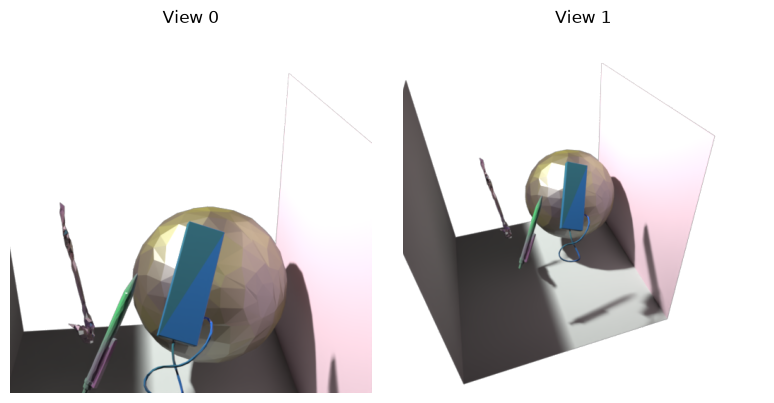

In [16]:
%tb
h5_path = "../tmp/streaming_dataset/nmr_dataset_chunk_0001.h5"
scene = "scene_0002"
view_scenes(h5_path=h5_path, scene=scene)